In [1]:
import os
import logging
import warnings
import optuna
import pandas as pd

from sklearn.metrics import mean_absolute_error

from src import engine, features
from src.preprocessing import preprocess_data
from src.settings import AppSettings
from notebook_utils import plot_actual_vs_predicted

# Read configuration from YAML file
config = AppSettings.from_yaml('./config.yaml')

# Set up logging
os.makedirs(config.path.log_dir, exist_ok=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO,
                    filename=config.path.logs,
                    format="%(levelname)s  %(message)s")

logger = logging.getLogger(__name__)


c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Nested cross-validation (out-of-fold predictions)

Run 3 outer folds, each test window equal to `FORECAST_HORIZON` steps per store. On every outer fold we tune hyperparameters on the training portion, refit with the best params, and predict the held-out test window. The out-of-fold predictions are then collected and plotted per store.


Outer fold 1/2
[0]	train-rmse:4.71648+0.00296	test-rmse:4.36812+0.28254
[0]	train-rmse:4.76271+0.00270	test-rmse:4.41261+0.28527
[0]	train-rmse:4.63375+0.00346	test-rmse:4.33189+0.32070
[100]	train-rmse:0.88764+0.00138	test-rmse:0.76230+0.05129
[100]	train-rmse:0.41196+0.01566	test-rmse:0.49519+0.29747
[100]	train-rmse:1.98194+0.00023	test-rmse:1.84870+0.11729
[200]	train-rmse:0.41958+0.00010	test-rmse:0.24693+0.00394
[151]	train-rmse:0.31578+0.00701	test-rmse:0.42921+0.23811
[300]	train-rmse:0.34135+0.00074	test-rmse:0.17635+0.00437
[400]	train-rmse:0.31814+0.00134	test-rmse:0.16766+0.00557
[404]	train-rmse:0.31800+0.00121	test-rmse:0.16766+0.00558

Outer fold 2/2
[0]	train-rmse:4.24070+0.00219	test-rmse:3.76140+0.41571
[0]	train-rmse:4.79208+0.00259	test-rmse:4.26577+0.46617
[0]	train-rmse:4.75213+0.00234	test-rmse:4.23574+0.45599
[59]	train-rmse:0.29768+0.00155	test-rmse:0.30459+0.04436
[100]	train-rmse:4.07480+0.00310	test-rmse:3.67179+0.41399
[200]	train-rmse:3.46773+0.00363	test

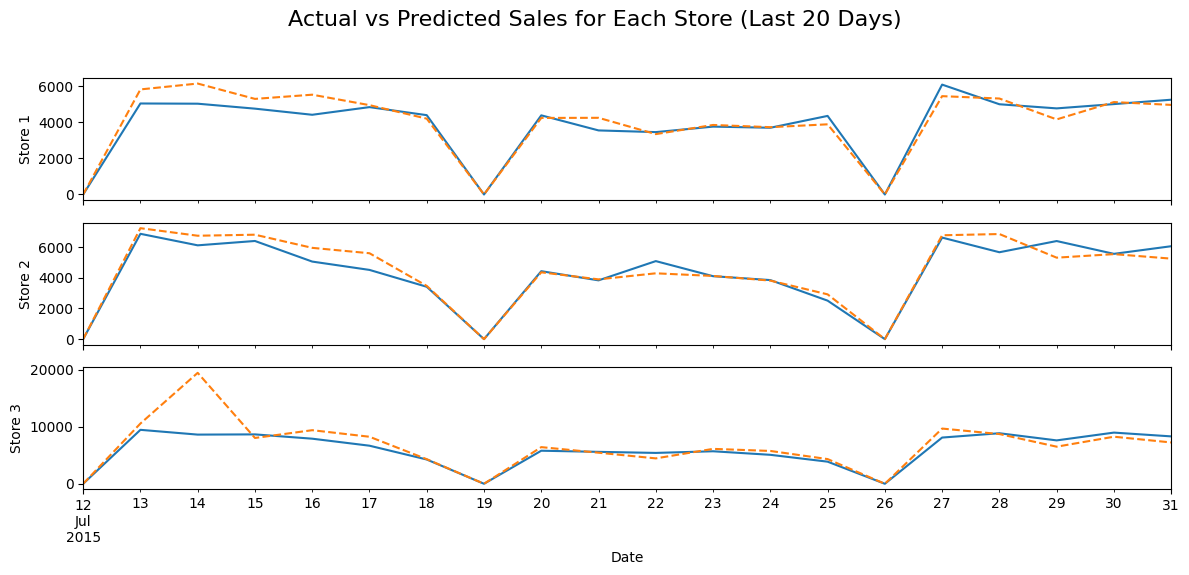

In [2]:


""" Read the Rossmann store sales dataset and preprocess it for modeling. """

sales = pd.read_csv(config.path.train)
stores = pd.read_csv(config.path.stores)

stores_to_use = [1, 2, 3]
stores = stores[stores['Store'].isin(stores_to_use)]

df = preprocess_data(sales, stores)

""" Generate features and target variable"""
trf = engine.TargetTransformer(
        forecast_horizon=pd.DateOffset(days=-config.horizon.days),
        anchor_col='lag_days_0')  # The anchor_col is the column used to align the target variable with the features. 
                                  # In this case, we use 'lag_days_0' which represents the sales on the current day.
                                  # It will be generated in the feature engineering step.

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: features.compute(df, config.feature_engineering, config.horizon)))

trf.fit(X)

y = df.set_index(['Store', 'Date'])['Sales']
y = trf.transform(y)    # forward difference target
X = X.loc[y.index]      # align features with target
X['subdivision']  = X['subdivision'].astype('category')   # convert subdivision to categorical dtype
X['holiday_name'] = X['holiday_name'].astype('category')  # convert holiday_name to categorical dtype


""" Perform nested cross-validation with hyperparameter tuning and model evaluation."""
num_days = X.index.get_level_values("Date").nunique()
cv_sizes = engine.compute_cv_sizes(num_days,
                                  config.horizon.days,
                                  config.cross_validation)

outer_cv = engine.TimeSeriesCV(
    n_splits=config.cross_validation.n_outer_splits,
    gap=config.horizon.days,
    train_size=cv_sizes['outer_train'],
    test_size=cv_sizes['outer_test'])

oof_preds = []
for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X), start=1):

    print(f"\nOuter fold {fold}/{config.cross_validation.n_outer_splits}")

    # Split the data into training and test sets for the current outer fold
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    # 1) Hyperparameter tuning on the outer-fold training data (embargoed inner CV inside optimize).
    study_name = f"nested_outer_{fold}"
    engine.optimize(study_name=study_name,
                    X_train=X_train,
                    y_train=y_train,
                    cv_settings=cv_sizes,
                    config=config)

    # 2) Refit on the outer-fold training data using the best hyperparameters.
    study = optuna.load_study(study_name=study_name,
                              storage=config.path.storage_url)

    model = engine.refit(X_train, y_train, study.best_trial, config.model_constants)

    # 3) Predict the held-out test window and store the out-of-fold predictions.
    fold_preds = engine.predict(X_test, model, trf)  # Use the utility function to get predictions
    oof_preds.append(fold_preds)


# Combine all out-of-fold predictions and invert the target transform.
oof_results = pd.merge(left=df.set_index(['Store', 'Date'])['Sales'],
                       right=pd.concat(oof_preds),
                       left_index=True,
                       right_index=True,
                       suffixes=('_actual', '_predicted')).sort_index()


oof_mae = mean_absolute_error(oof_results["Sales_actual"], oof_results["Sales_predicted"])
print(f"\nOut-of-fold MAE: {oof_mae:.2f}")
plot_actual_vs_predicted(oof_results, 
                         n_days_to_plot=config.horizon.days * config.cross_validation.n_outer_splits, 
                         n_days_offset=0)